# PKI kinase inhibitors → AnnData

Protein kinase inhibitors profiled in the [Cell Painting Gallery](https://broadinstitute.github.io/cellpainting-gallery/) (`cpg0008-pki`), one batch of eight plates with dose and mechanism-of-action annotation.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_negcon_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0008-pki/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0008-pki/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
print(f"{len(files)} plates")

8 plates


In [3]:
adata = cpio.read_profiles(files, index_columns=["Plate", "Well"])
adata

AnnData object with n_obs × n_vars = 3072 × 1061
    obs: 'plate_map_name', 'broad_sample', 'mg_per_ml', 'mmoles_per_liter', 'solvent', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count', 'Barcode', 'Supplier', 'Supplier_Catalog', 'moa', 'pert_type', 'control_type'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "pert_type", "control_type", "moa", "mmoles_per_liter"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_AGP,image,granularity,agp,NaN,1
Image_Granularity_10_BFHigh,image,granularity,brightfield_high,NaN,1
Image_Granularity_10_BFLow,image,granularity,brightfield_low,NaN,1
Image_Granularity_10_Brightfield,image,granularity,brightfield,NaN,1
Image_Granularity_10_Mito,image,granularity,mito,NaN,1
...,...,...,...,...,...
Nuclei_Texture_InfoMeas2_BFLow_3_00_256,nuclei,texture,brightfield_low,NaN,1
Nuclei_Texture_InfoMeas2_Mito_3_00_256,nuclei,texture,mito,NaN,1
Nuclei_Texture_SumVariance_AGP_10_03_256,nuclei,texture,agp,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["pert_type", "control_type", "mmoles_per_liter"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

3,072 wells x 1,061 features
non-finite: 0 | max|x|: 7912.3

pert_type:
pert_type
trt        2112
control     960

control_type:
control_type
NaN       2112
negcon     832
poscon     128

mmoles_per_liter:
mmoles_per_liter
NaN       832
 0.040    512
 0.200    512
 0.400    512
 0.004    192
 0.010    192


In [6]:
adata.write_h5ad(PROFILES.parent / "pki.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "pert_type", "moa", "mmoles_per_liter"]))

,observed,baseline,ratio
covariate,,,
Plate,0.437,0.125,3.494
pert_type,0.786,0.570,1.378
moa,0.213,0.096,2.208
mmoles_per_liter,0.210,0.182,1.156


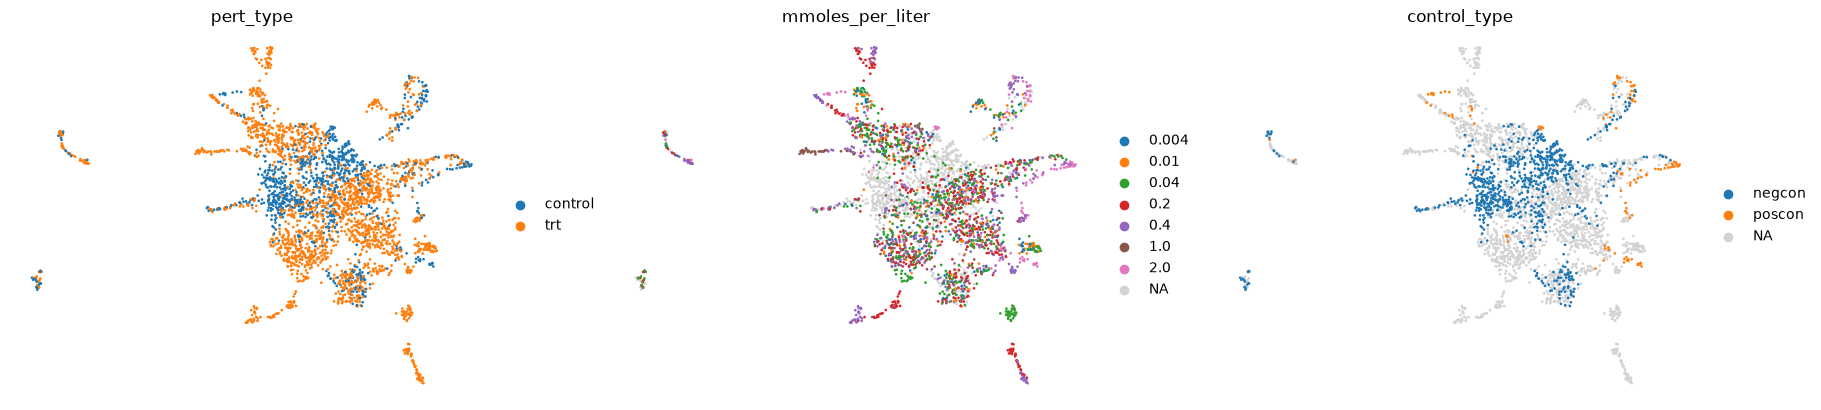

In [9]:
sc.pl.umap(
    adata,
    color=present(["pert_type", "mmoles_per_liter", "control_type", "Plate"])[:3],
    ncols=3,
    frameon=False,
    size=15,
)